In [1]:
# Common libs
import pandas as pd
import numpy as np
import sys
import random
from pathlib import Path
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# Image processing
#from skimage.transform import rescale, resize

import skimage 
from skimage import transform

# Charts
import matplotlib.pyplot as plt
import seaborn as sns


# ML
import scipy
from sklearn.model_selection import train_test_split
from sklearn import metrics


import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models


# Set random seed to make results reproducable
np.random.seed(42)
tf.random.set_seed(42)

# Global variables
img_folder='/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs'
img_width=100
img_height=100
img_channels=3

/kaggle/input/honey-bee-annotated-images/bee_data.csv
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/041_057.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/022_171.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/027_012.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/015_1171.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/038_178.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/032_305.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/005_542.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/038_449.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/005_543.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/035_023.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/032_891.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/021_172.png
/kaggle/input/honey-bee-annotated-images/bee_imgs/bee_imgs/019_1169.png
/kaggle/input/honey-b

In [2]:
bees=pd.read_csv("/kaggle/input/honey-bee-annotated-images/bee_data.csv", 
                index_col=False,  
                dtype={'subspecies':'category', 'health':'category','caste':'category'})

In [3]:
bees['file'] = img_folder+'/'+bees['file']

In [4]:
def read_and_resize(file_name,size=(224,224)):
    image = skimage.io.imread(file_name)
    image = skimage.transform.resize(image, size,mode='reflect',anti_aliasing=True)
    return image[:,:,:3]

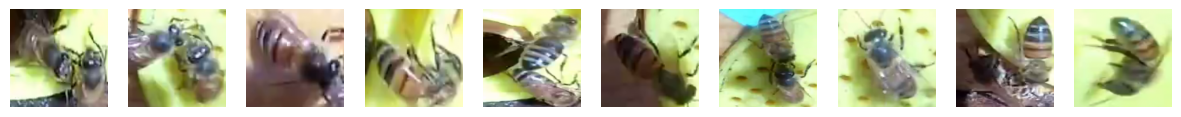

In [5]:
plt.figure(figsize=(15,15))
for i in range(20,30):
    plt.subplot(10,10, i+1)
    plt.imshow(read_and_resize(bees['file'][i]))
    plt.axis('off')

plt.show()

In [6]:
train,test = train_test_split(bees,test_size=0.2,shuffle=True,random_state=42)

In [7]:
train , val = train_test_split(train,test_size=0.2,shuffle=True,random_state=42)

In [8]:
train.shape,test.shape,val.shape

((3309, 9), (1035, 9), (828, 9))

In [9]:
train_x = np.stack(train['file'].apply(read_and_resize))
train_y = pd.get_dummies(train['health'])

In [10]:
test_x = np.stack(test['file'].apply(read_and_resize))
test_y = pd.get_dummies(test['health'])
val_x = np.stack(val['file'].apply(read_and_resize))
val_y = pd.get_dummies(val['health'])

In [11]:
train_x.shape

(3309, 224, 224, 3)

In [12]:
train_x = tf.cast(train_x,dtype=tf.float32)
train_y = tf.cast(train_y,dtype=tf.float32)
val_x = tf.cast(val_x,dtype=tf.float32)
val_y = tf.cast(val_y,dtype=tf.float32)


In [13]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_x, train_y)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((val_x, val_y)).batch(32)

In [ ]:
x = tf.keras.layers.Input()

In [24]:
history = compile_and_train(model,train_dataset,val_dataset,learning_rate=0.01,epochs=5)

Epoch 1/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 24s 132ms/step - accuracy: 0.5494 - loss: 3.1419 - val_accuracy: 0.6763 - val_loss: 1.0838
Epoch 2/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - accuracy: 0.6523 - loss: 1.2171 - val_accuracy: 0.6763 - val_loss: 1.0705
Epoch 3/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.6523 - loss: 1.1951 - val_accuracy: 0.6763 - val_loss: 1.0895
Epoch 4/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.6523 - loss: 1.1732 - val_accuracy: 0.6763 - val_loss: 1.0906
Epoch 5/5
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.6523 - loss: 1.1465 - val_accuracy: 0.6763 - val_loss: 1.0881


In [35]:
test_x = tf.cast(test_x,tf.float32)
test_y = tf.cast(test_y,tf.float32)

In [26]:
model.predict(test_x)

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 162ms/step


array([[0.10077742, 0.09236041, 0.11089924, 0.63082206, 0.05462045,
        0.01052048],
       [0.10077742, 0.09236041, 0.11089924, 0.63082206, 0.05462045,
        0.01052048],
       [0.10077742, 0.09236041, 0.11089924, 0.63082206, 0.05462045,
        0.01052048],
       ...,
       [0.10077742, 0.09236041, 0.11089924, 0.63082206, 0.05462045,
        0.01052048],
       [0.10077742, 0.09236041, 0.11089924, 0.63082206, 0.05462045,
        0.01052048],
       [0.10077742, 0.09236041, 0.11089924, 0.63082206, 0.05462045,
        0.01052048]], dtype=float32)

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
# Make predictions
predictions = model.predict(test_x)

# Convert predictions to class labels
predicted_classes = tf.argmax(predictions, axis=1)

# Evaluate accuracy
accuracy = tf.reduce_mean(tf.cast(predicted_classes == tf.argmax(test_y, axis=1), tf.float32))
print(f'Accuracy: {accuracy:.4f}')

# Classification report and confusion matrix
print(classification_report(tf.argmax(test_y, axis=1), predicted_classes))



33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step
Accuracy: 0.6667
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        84
           1       0.00      0.00      0.00        87
           2       0.00      0.00      0.00       114
           3       0.67      1.00      0.80       690
           4       0.00      0.00      0.00        51
           5       0.00      0.00      0.00         9

    accuracy                           0.67      1035
   macro avg       0.11      0.17      0.13      1035
weighted avg       0.44      0.67      0.53      1035



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [29]:
confusion_matrix(tf.argmax(test_y, axis=1), predicted_classes)

array([[  0,   0,   0,  84,   0,   0],
       [  0,   0,   0,  87,   0,   0],
       [  0,   0,   0, 114,   0,   0],
       [  0,   0,   0, 690,   0,   0],
       [  0,   0,   0,  51,   0,   0],
       [  0,   0,   0,   9,   0,   0]])

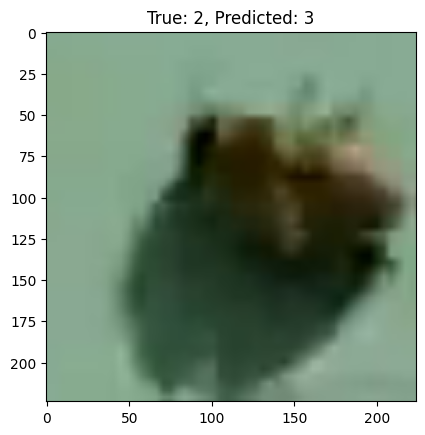

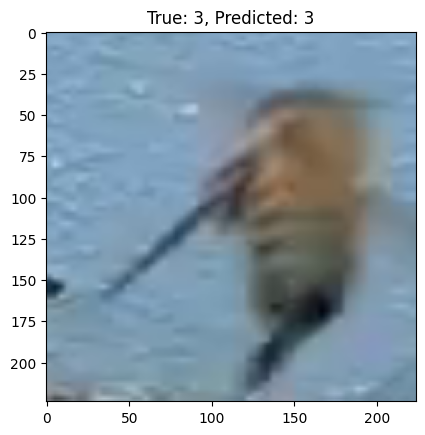

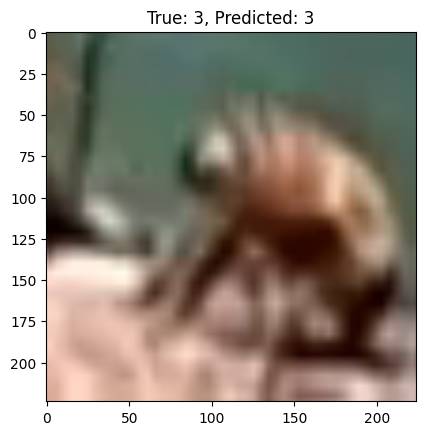

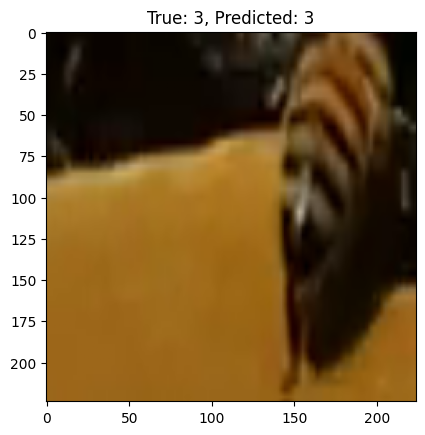

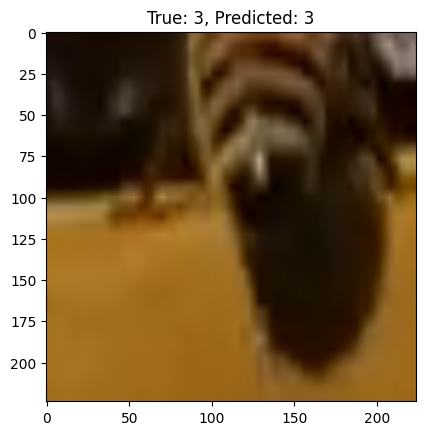

In [30]:
for i in range(5):
    plt.imshow(test_x[i])
    plt.title(f"True: {tf.argmax(test_y[i])}, Predicted: {predicted_classes[i]}")
    plt.show()

In [32]:
# Prepare the test dataset
test_dataset = (test_x, test_y)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_x, test_y)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')


33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.6592 - loss: 1.1421
Test Loss: 1.1187, Test Accuracy: 0.6667
